# Домашнее задание: предсказание рейтинга отзывов об отелях

В этом ноутбуке решается задача **многоклассовой классификации**: по тексту отзыва нужно предсказать рейтинг от **1 до 5**.

## Основная метрика
Так как классы распределены  супер неравномерно (рейтинг 5 прям каннибализировать может все), основной метрикой для выбора лучшей модели будет **macro F1**.  
`Accuracy` также считаем, но интерпретируем как дополнительную метрику.


## 1. Импорты и воспроизводимость

Фиксируем `random_state`, seed'ы для `random`, `numpy` и `torch`, а также включаем максимально воспроизводимый режим вычислений.  
На одной и той же видеокарте и при одном и том же стеке `PyTorch / CUDA / cuDNN` результаты должны повторяться существенно надёжнее.

Для ускорения ноутбук использует **CUDA**, если видеокарта доступна. При этом в режиме строгой воспроизводимости отключаются TF32 и mixed precision, потому что они ускоряют обучение, но ухудшают повторяемость.


In [1]:
import os
# Для детерминированных CUDA-операций переменная должна быть задана до первых вызовов CUDA
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

import re
import copy
import time
import random
import warnings
from contextlib import nullcontext
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
STRICT_REPRODUCIBILITY = True  # True -> максимальная повторяемость результатов на той же CUDA/GPU
USE_CUDA_IF_AVAILABLE = True

def set_seed(seed: int = 42, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        # Для воспроизводимости отключаем автотюнинг и приближённую математику
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        torch.set_float32_matmul_precision('highest')
        torch.use_deterministic_algorithms(True, warn_only=True)
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision('high')
        torch.use_deterministic_algorithms(False)

set_seed(SEED, deterministic=STRICT_REPRODUCIBILITY)

DEVICE = torch.device('cuda:0' if (USE_CUDA_IF_AVAILABLE and torch.cuda.is_available()) else 'cpu')

# Для строгой повторяемости mixed precision лучше отключить.
USE_AMP = DEVICE.type == 'cuda' and not STRICT_REPRODUCIBILITY
AMP_DTYPE = torch.float16
NON_BLOCKING = DEVICE.type == 'cuda'

if DEVICE.type == 'cuda':
    GPU_NAME = torch.cuda.get_device_name(0)
    print(f'Используется GPU: {GPU_NAME}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'STRICT_REPRODUCIBILITY={STRICT_REPRODUCIBILITY}')
    print(f'USE_AMP={USE_AMP}')
    print(f'cudnn.deterministic={torch.backends.cudnn.deterministic}')
    print(f'cudnn.benchmark={torch.backends.cudnn.benchmark}')
else:
    GPU_NAME = None
    torch.set_num_threads(max(1, (os.cpu_count() or 1) // 2))
    print('CUDA не найдена, ноутбук будет работать на CPU.')

DEVICE


Используется GPU: NVIDIA GeForce RTX 5070 Ti
CUDA version: 12.9
STRICT_REPRODUCIBILITY=True
USE_AMP=False
cudnn.deterministic=True
cudnn.benchmark=False


device(type='cuda', index=0)

## 2. Загрузка данных

Ниже используется публичный CSV-файл с датасетом.

In [2]:
DATA_FILENAME = 'tripadvisor_hotel_reviews.csv'
DATA_URL = 'https://raw.githubusercontent.com/theleadio/datascience_demo/master/tripadvisor_hotel_reviews.csv'

candidate_paths = [
    os.path.join(os.getcwd(), DATA_FILENAME),
    os.path.join('/mnt/data', DATA_FILENAME),
]

DATA_PATH = None
for path in candidate_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    import urllib.request
    DATA_PATH = DATA_FILENAME
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)


df = pd.read_csv(DATA_PATH)
print('Файл:', DATA_PATH)
print('Форма:', df.shape)
df.head()


Файл: c:\Users\admin\coding\notebooks\nlp_course\homework_2\tripadvisor_hotel_reviews.csv
Форма: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Посмотрим на распределение целевой переменной. Классы несбалансированы: отзывов с высокими рейтингами заметно больше, чем с низкими. Поэтому кроме accuracy далее будем смотреть на **macro F1**.

Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


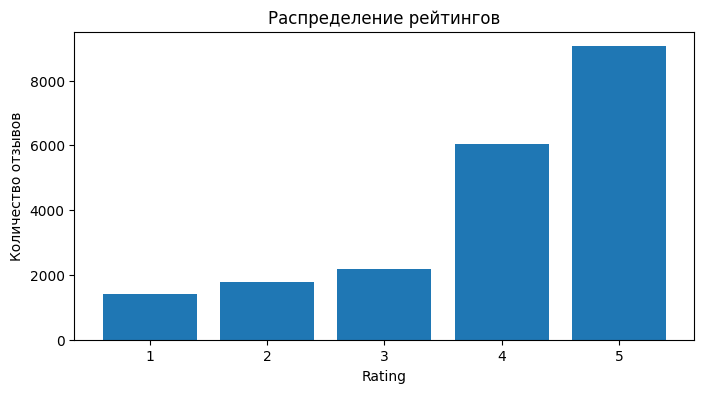

In [3]:
rating_dist = df['Rating'].value_counts().sort_index()
print(rating_dist)

plt.figure(figsize=(8, 4))
plt.bar(rating_dist.index.astype(str), rating_dist.values)
plt.title('Распределение рейтингов')
plt.xlabel('Rating')
plt.ylabel('Количество отзывов')
plt.show()

## 3. Предобработка текста

Для этой задачи не нужна слишком агрессивная очистка. Я оставляю достаточно простой, но устойчивый пайплайн:

- приведение к нижнему регистру;
- удаление цифр, пунктуации и лишних символов;
- нормализация пробелов.

Лемматизацию здесь не использую: датасет англоязычный, а для базовых нейросетевых моделей в этой задаче хватает нормализации и токенизации по пробелам.

In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z']+", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['text_clean'] = df['Review'].map(clean_text)
df = df[df['text_clean'].str.len() > 0].copy()
df['label'] = df['Rating'].astype(int) - 1  # 0..4 вместо 1..5

print(df[['Review', 'text_clean', 'Rating', 'label']].head(3))

                                              Review  \
0  nice hotel expensive parking got good deal sta...   
1  ok nothing special charge diamond member hilto...   
2  nice rooms not 4* experience hotel monaco seat...   

                                          text_clean  Rating  label  
0  nice hotel expensive parking got good deal sta...       4      3  
1  ok nothing special charge diamond member hilto...       2      1  
2  nice rooms not experience hotel monaco seattle...       3      2  


## 4. Разбиение на train / valid / test

Используем стратификацию, чтобы распределение классов было максимально близким во всех выборках.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_clean'],
    df['label'],
    test_size=0.4,
    random_state=SEED,
    stratify=df['label']
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f'train: {len(X_train)}')
print(f'valid: {len(X_valid)}')
print(f'test : {len(X_test)}')

train: 12294
valid: 4098
test : 4099


In [6]:
def show_distribution(name, y):
    dist = pd.Series(y).value_counts(normalize=True).sort_index().rename(index=lambda x: x + 1)
    print(f"\n{name}")
    print((dist * 100).round(2).astype(str) + '%')

show_distribution('Train', y_train)
show_distribution('Valid', y_valid)
show_distribution('Test', y_test)

total = len(df)
print(f"\nИтого объектов после очистки: {total}")
print(f"train/valid/test = {len(X_train)}/{len(X_valid)}/{len(X_test)}")
print(f"Доли: {len(X_train)/total:.2%} / {len(X_valid)/total:.2%} / {len(X_test)/total:.2%}")



Train
label
1     6.94%
2     8.75%
3    10.66%
4    29.47%
5    44.18%
Name: proportion, dtype: object

Valid
label
1     6.93%
2     8.74%
3    10.66%
4    29.48%
5    44.19%
Name: proportion, dtype: object

Test
label
1     6.93%
2     8.76%
3    10.66%
4    29.47%
5    44.18%
Name: proportion, dtype: object

Итого объектов после очистки: 20491
train/valid/test = 12294/4098/4099
Доли: 60.00% / 20.00% / 20.00%


## 5. Выбор batch size и режим вычислений

### Как выбирается batch size
Требование задания звучит как «выберите оптимальный, на ваш взгляд, `batch_size`».  
Понял это как баланс между:
- скоростью обучения;
- устойчивостью сходимости;
- ограничениями памяти видеокарты;
- воспроизводимостью.

В режиме **строгой воспроизводимости** я выбираю более консервативный размер батча:
- на GPU: `BATCH_SIZE = 192`;
- на CPU: `BATCH_SIZE = 64`.

Для валидации и теста батч можно сделать крупнее, потому что градиенты там не считаются.

### Почему не выбран максимально большой батч
Слишком большой батч не всегда улучшает качество:  
он ускоряет одну эпоху, но может ухудшать обобщающую способность и сильнее упираться в память, особенно для LSTM.


## 6. Токенизация и словарь

Словарь строим **только по train-части**, чтобы не допускать утечки информации. Неизвестные слова заменяются на `<unk>`, короткие последовательности дополняются `<pad>`.

In [7]:
MAX_VOCAB = 10000
MAX_LEN = 100

if DEVICE.type == 'cuda':
    if STRICT_REPRODUCIBILITY:
        BATCH_SIZE = 192
        EVAL_BATCH_SIZE = 256
        NUM_WORKERS = 0
    else:
        BATCH_SIZE = 256
        EVAL_BATCH_SIZE = 512
        NUM_WORKERS = min(4, os.cpu_count() or 0)
else:
    BATCH_SIZE = 64
    EVAL_BATCH_SIZE = 128
    NUM_WORKERS = 0

PIN_MEMORY = DEVICE.type == 'cuda'
PERSISTENT_WORKERS = NUM_WORKERS > 0

counter = Counter()
for text in X_train:
    counter.update(text.split())

itos = ['<pad>', '<unk>'] + [word for word, _ in counter.most_common(MAX_VOCAB - 2)]
stoi = {word: idx for idx, word in enumerate(itos)}

PAD_IDX = stoi['<pad>']
UNK_IDX = stoi['<unk>']

print('Размер словаря:', len(itos))
print('Максимальная длина последовательности:', MAX_LEN)
print('Выбранный train batch size:', BATCH_SIZE)
print('Выбранный eval batch size :', EVAL_BATCH_SIZE)
print('DataLoader workers:', NUM_WORKERS)
print('Pin memory:', PIN_MEMORY)
print('STRICT_REPRODUCIBILITY:', STRICT_REPRODUCIBILITY)
print('Первые токены словаря:', itos[:15])


Размер словаря: 10000
Максимальная длина последовательности: 100
Выбранный train batch size: 192
Выбранный eval batch size : 256
DataLoader workers: 0
Pin memory: True
STRICT_REPRODUCIBILITY: True
Первые токены словаря: ['<pad>', '<unk>', 'hotel', 'room', 'not', 'great', "n't", 'good', 'staff', 'stay', 'did', 'just', 'rooms', 'nice', 'no']


In [8]:
def encode_text(text: str, max_len: int = MAX_LEN):
    tokens = text.split()
    token_ids = [stoi.get(token, UNK_IDX) for token in tokens[:max_len]]
    length = len(token_ids)
    token_ids += [PAD_IDX] * (max_len - length)
    return token_ids, length


def encode_texts(texts, max_len: int = MAX_LEN):
    texts = list(texts)
    input_ids = np.full((len(texts), max_len), PAD_IDX, dtype=np.int64)
    lengths = np.zeros(len(texts), dtype=np.int64)

    for i, text in enumerate(texts):
        token_ids, length = encode_text(text, max_len=max_len)
        input_ids[i] = token_ids
        lengths[i] = length

    return torch.from_numpy(input_ids), torch.from_numpy(lengths)


class ReviewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.input_ids, self.lengths = encode_texts(texts)
        self.labels = torch.as_tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.lengths[idx],
            self.labels[idx]
        )


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


generator = torch.Generator().manual_seed(SEED)

train_ds = ReviewsDataset(X_train, y_train)
valid_ds = ReviewsDataset(X_valid, y_valid)
test_ds  = ReviewsDataset(X_test, y_test)

loader_common_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': PIN_MEMORY,
    'worker_init_fn': seed_worker,
}

if PERSISTENT_WORKERS:
    loader_common_kwargs['persistent_workers'] = True

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    **loader_common_kwargs
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_common_kwargs
)

test_loader = DataLoader(
    test_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_common_kwargs
)

sample_batch = next(iter(train_loader))
[x.shape for x in sample_batch]

[torch.Size([192, 100]), torch.Size([192]), torch.Size([192])]

## 7. Архитектуры моделей

Реализовал три модели (последняя как улучшенная):

1. **CNN baseline** — простая сверточная сеть с одним Conv1d-слоем и глобальным max-pooling.
2. **LSTM baseline** — рекуррентная сеть с одним LSTM-слоем.
3. **Improved TextCNN** — улучшенная сверточная модель с несколькими ядрами свертки (3, 5, 7), что позволяет ловить n-граммы разной длины. Также больше фильтров и размер эмбединга.

In [9]:
class CNNBaseline(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 64, num_classes: int = 5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv = nn.Conv1d(embed_dim, 96, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(96, num_classes)

    def forward(self, input_ids, lengths=None):
        x = self.embedding(input_ids)          # [B, L, E]
        x = x.transpose(1, 2)                  # [B, E, L]
        x = torch.relu(self.conv(x))           # [B, C, L]
        x = torch.max(x, dim=2).values         # global max-pooling
        x = self.dropout(x)
        return self.fc(x)


class LSTMBaseline(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 64, hidden_dim: int = 64, num_classes: int = 5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        x = self.dropout(hidden[-1])
        return self.fc(x)


class TextCNNImproved(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 96, num_classes: int = 5, num_filters: int = 96):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=3, padding=1),
            nn.Conv1d(embed_dim, num_filters, kernel_size=5, padding=2),
            nn.Conv1d(embed_dim, num_filters, kernel_size=7, padding=3),
        ])
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(num_filters * len(self.convs), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids, lengths=None):
        x = self.embedding(input_ids)   # [B, L, E]
        x = x.transpose(1, 2)           # [B, E, L]

        conv_features = []
        for conv in self.convs:
            h = torch.relu(conv(x))
            pooled = torch.max(h, dim=2).values
            conv_features.append(pooled)

        x = torch.cat(conv_features, dim=1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

## 8. Вспомогательные функции для обучения

Для оценки используем:
- **loss**;
- **accuracy**;
- **macro F1**.

Главная метрика для выбора лучшей эпохи — **macro F1**, потому что классы супер несбалансированы.  
Сохраняем лучшую эпоху по валидационной `macro F1`, используем `early stopping`, а после обучения оцениваем модели на тесте.


In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro')
    }


def build_optimizer(model, lr: float):
    # fused AdamW быстрее, но для строгой воспроизводимости лучше обычный AdamW
    if DEVICE.type == 'cuda' and not STRICT_REPRODUCIBILITY:
        try:
            return torch.optim.AdamW(model.parameters(), lr=lr, fused=True)
        except TypeError:
            pass
    return torch.optim.AdamW(model.parameters(), lr=lr)


def autocast_context():
    if USE_AMP:
        return torch.autocast(device_type='cuda', dtype=AMP_DTYPE)
    return nullcontext()


def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    criterion = nn.CrossEntropyLoss().to(DEVICE)
    all_losses = []
    all_preds = []
    all_targets = []

    grad_context = torch.enable_grad() if is_train else torch.no_grad()

    with grad_context:
        for input_ids, lengths, targets in loader:
            input_ids = input_ids.to(DEVICE, non_blocking=NON_BLOCKING)
            # lengths оставляем на CPU: pack_padded_sequence для LSTM и так ожидает lengths на CPU
            targets = targets.to(DEVICE, non_blocking=NON_BLOCKING)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                logits = model(input_ids, lengths)
                loss = criterion(logits, targets)

            if is_train:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            preds = logits.argmax(dim=1)

            all_losses.append(loss.detach().float().item())
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())

    metrics = compute_metrics(all_targets, all_preds)
    metrics['loss'] = float(np.mean(all_losses))
    return metrics, np.asarray(all_targets), np.asarray(all_preds)


def fit_model(model, train_loader, valid_loader, epochs=8, lr=1e-3, patience=3):
    optimizer = build_optimizer(model, lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {
        'train_loss': [], 'valid_loss': [],
        'train_accuracy': [], 'valid_accuracy': [],
        'train_macro_f1': [], 'valid_macro_f1': []
    }

    best_state = None
    best_score = -np.inf
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, optimizer, scaler=scaler)
        valid_metrics, _, _ = run_epoch(model, valid_loader)

        history['train_loss'].append(train_metrics['loss'])
        history['valid_loss'].append(valid_metrics['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['valid_accuracy'].append(valid_metrics['accuracy'])
        history['train_macro_f1'].append(train_metrics['macro_f1'])
        history['valid_macro_f1'].append(valid_metrics['macro_f1'])

        print(
            f"Epoch {epoch:02d} | "
            f"train loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.4f}, f1={train_metrics['macro_f1']:.4f} | "
            f"valid loss={valid_metrics['loss']:.4f}, acc={valid_metrics['accuracy']:.4f}, f1={valid_metrics['macro_f1']:.4f}"
        )

        current_score = valid_metrics['macro_f1']
        if current_score > best_score:
            best_score = current_score
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


@torch.no_grad()
def evaluate_model(model, loader):
    return run_epoch(model, loader)


In [11]:
!nvidia-smi --query-gpu=name,temperature.gpu,utilization.gpu,utilization.memory,memory.used,memory.total,power.draw --format=csv


name, temperature.gpu, utilization.gpu [%], utilization.memory [%], memory.used [MiB], memory.total [MiB], power.draw [W]
NVIDIA GeForce RTX 5070 Ti, 44, 0 %, 0 %, 1562 MiB, 16303 MiB, 46.30 W


In [12]:
EPOCHS = 30
PATIENCE = 5

MODEL_BUILDERS = {
    'CNN baseline': lambda: CNNBaseline(len(itos), embed_dim=64),
    'LSTM baseline': lambda: LSTMBaseline(len(itos), embed_dim=64, hidden_dim=64),
    'Improved TextCNN': lambda: TextCNNImproved(len(itos), embed_dim=96, num_filters=96),
}

print(f'Модели будут обучаться на устройстве: {DEVICE}')
for name, builder in MODEL_BUILDERS.items():
    temp_model = builder()
    print(f'{name}: {count_parameters(temp_model):,} trainable parameters')
    del temp_model


Модели будут обучаться на устройстве: cuda:0
CNN baseline: 659,013 trainable parameters
LSTM baseline: 673,605 trainable parameters
Improved TextCNN: 1,136,165 trainable parameters


## 9. Обучение моделей

In [13]:
histories = {}
results = []
fitted_models = {}

for model_name, model_builder in MODEL_BUILDERS.items():
    print('=' * 100)
    print(model_name)
    print('=' * 100)

    # Фиксируем seed до инициализации модели, чтобы стартовые веса были воспроизводимы.
    set_seed(SEED, deterministic=STRICT_REPRODUCIBILITY)
    model = model_builder().to(DEVICE)

    start_time = time.perf_counter()
    history = fit_model(
        model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        epochs=EPOCHS,
        lr=1e-3,
        patience=PATIENCE
    )
    elapsed = time.perf_counter() - start_time

    valid_metrics, _, _ = evaluate_model(model, valid_loader)
    test_metrics, y_true_test, y_pred_test = evaluate_model(model, test_loader)

    histories[model_name] = history
    fitted_models[model_name] = model

    results.append({
        'model': model_name,
        'epochs_ran': len(history['train_loss']),
        'train_time_sec': round(elapsed, 2),
        'best_valid_accuracy': valid_metrics['accuracy'],
        'best_valid_macro_f1': valid_metrics['macro_f1'],
        'test_accuracy': test_metrics['accuracy'],
        'test_macro_f1': test_metrics['macro_f1'],
        'test_loss': test_metrics['loss']
    })


CNN baseline
Epoch 01 | train loss=1.4744, acc=0.3856, f1=0.1973 | valid loss=1.3131, acc=0.4536, f1=0.1541
Epoch 02 | train loss=1.2681, acc=0.4624, f1=0.2415 | valid loss=1.2203, acc=0.4697, f1=0.1947
Epoch 03 | train loss=1.1781, acc=0.5004, f1=0.3277 | valid loss=1.1164, acc=0.5229, f1=0.3329
Epoch 04 | train loss=1.1105, acc=0.5274, f1=0.3837 | valid loss=1.0826, acc=0.5276, f1=0.3452
Epoch 05 | train loss=1.0584, acc=0.5478, f1=0.4242 | valid loss=1.0402, acc=0.5539, f1=0.4200
Epoch 06 | train loss=1.0252, acc=0.5608, f1=0.4426 | valid loss=1.0168, acc=0.5522, f1=0.4238
Epoch 07 | train loss=1.0010, acc=0.5713, f1=0.4665 | valid loss=1.0031, acc=0.5647, f1=0.4273
Epoch 08 | train loss=0.9754, acc=0.5781, f1=0.4752 | valid loss=0.9888, acc=0.5656, f1=0.4458
Epoch 09 | train loss=0.9544, acc=0.5952, f1=0.4954 | valid loss=0.9892, acc=0.5591, f1=0.4391
Epoch 10 | train loss=0.9412, acc=0.5988, f1=0.5056 | valid loss=0.9682, acc=0.5759, f1=0.4640
Epoch 11 | train loss=0.9032, acc=0.6

## 10. Сравнение моделей

Соберём результаты в одну таблицу.  
Лучшей считаем модель с максимальным значением **test macro F1**.  
Дополнительно смотрим на `accuracy`, `loss`, число отработанных эпох и время обучения.


In [14]:
comparison_df = (
    pd.DataFrame(results)
    .sort_values(['test_macro_f1', 'test_accuracy'], ascending=False)
    .reset_index(drop=True)
)
comparison_df


,model,epochs_ran,train_time_sec,best_valid_accuracy,best_valid_macro_f1,test_accuracy,test_macro_f1,test_loss
0,Improved TextCNN,19,7.74,0.590532,0.515348,0.601610,0.523288,0.904682
1,CNN baseline,24,5.94,0.586140,0.505716,0.593315,0.517140,0.897180
2,LSTM baseline,22,18.35,0.563690,0.485402,0.556721,0.483850,1.100579


Improved TextCNN оказалась лучше по `accuracy` и `macro F1`.  
Так как классы несбалансированы, для итогового выбора я ориентируюсь прежде всего на **test_macro_f1**.

Также полезно смотреть:
- **train_time_sec** — насколько модель тяжёлая по времени;
- **epochs_ran** — как быстро сработал `early stopping`;
- разницу между train и valid на графиках ниже — она показывает признаки переобучения.


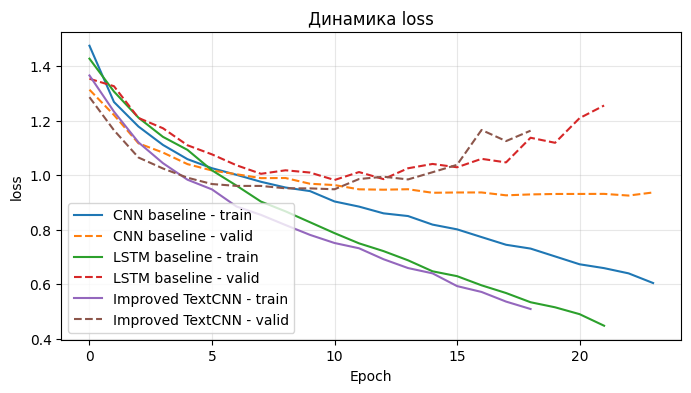

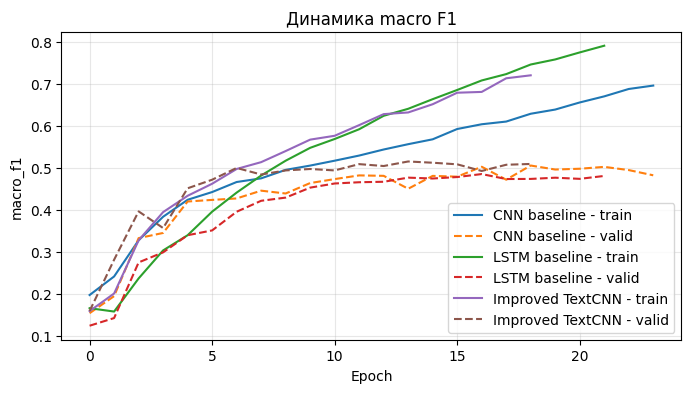

In [15]:
def plot_metric(histories, metric_name, title):
    plt.figure(figsize=(8, 4))
    for model_name, history in histories.items():
        plt.plot(history[f'train_{metric_name}'], label=f'{model_name} - train')
        plt.plot(history[f'valid_{metric_name}'], linestyle='--', label=f'{model_name} - valid')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_metric(histories, 'loss', 'Динамика loss')
plot_metric(histories, 'macro_f1', 'Динамика macro F1')

## 11. Отчёт по лучшей модели на тесте

In [16]:
best_model_name = comparison_df.iloc[0]['model']
best_model = fitted_models[best_model_name]

best_metrics, y_true_test, y_pred_test = evaluate_model(best_model, test_loader)

print('Лучшая модель:', best_model_name)
print(best_metrics)
print()
print(classification_report(y_true_test + 1, y_pred_test + 1, digits=4))

Лучшая модель: Improved TextCNN
{'accuracy': 0.6016101488167845, 'macro_f1': 0.5232881259657651, 'loss': 0.9046816194758696}

              precision    recall  f1-score   support

           1     0.6232    0.6056    0.6143       284
           2     0.3907    0.3983    0.3945       359
           3     0.4078    0.2632    0.3199       437
           4     0.4929    0.6026    0.5423      1208
           5     0.7703    0.7223    0.7455      1811

    accuracy                         0.6016      4099
   macro avg     0.5370    0.5184    0.5233      4099
weighted avg     0.6065    0.6016    0.6004      4099



## 12. Итоговые выводы



In [18]:
best_row = comparison_df.iloc[0]
worst_row = comparison_df.iloc[-1]

final_conclusion = (
    f"Итог:\n"
    f"1. Лучший результат на тесте показала модель: {best_row['model']}.\n"
    f"2. Её test accuracy = {best_row['test_accuracy']:.4f}, test macro F1 = {best_row['test_macro_f1']:.4f}.\n"
    f"3. Самой слабой по test macro F1 оказалась модель: {worst_row['model']}.\n"
    f"4. CNN обучается быстрее LSTM и даёт сильный базовый результат.\n"
    f"5. Улучшение CNN через несколько размеров ядер позволяет лучше ловить локальные шаблоны текста разной длины.\n"
    f"6. Для этой задачи macro F1 важнее accuracy, потому что классы распределены супер неравномерно.\n"
)

print(final_conclusion)


Итог:
1. Лучший результат на тесте показала модель: Improved TextCNN.
2. Её test accuracy = 0.6016, test macro F1 = 0.5233.
3. Самой слабой по test macro F1 оказалась модель: LSTM baseline.
4. CNN обучается быстрее LSTM и даёт сильный базовый результат.
5. Улучшение CNN через несколько размеров ядер позволяет лучше ловить локальные шаблоны текста разной длины.
6. Для этой задачи macro F1 важнее accuracy, потому что классы распределены супер неравномерно.

